# Buyer Credit Risk: EDA & Model Development

Walks through the data, the label definition, a baseline-vs-model comparison, and the evaluation
methodology behind the score used in `app.py`. Everything here operates on the **synthetic**
sample data in `data/` (see `creditrisk/generate.py`) -- it demonstrates the method, not real
portfolio performance.

Run from the repository root: `jupyter notebook notebooks/01_eda_and_model_development.ipynb`.


In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from creditrisk import evaluate, generate
from creditrisk.config import SETTINGS
from creditrisk.features import feature_columns
from creditrisk.model import build_dataset, data_end_date, new_model, snapshot_dates

plt.rcParams["figure.figsize"] = (6, 4)
pd.set_option("display.max_columns", 40)


## 1. The data

Two tables, mirroring an ERP export: one row per buyer, one row per invoice.

In [2]:
buyers, invoices = generate.generate(n_buyers=400, seed=7)
print(buyers.shape, invoices.shape)
buyers.head()


(400, 7) (11622, 7)


,buyer_id,buyer_name,country,segment,onboarded_date,credit_limit,payment_terms_days
0,B0001,Harbor Trading 1,UAE,Online brand,2024-03-25,27000,30
1,B0002,Urban Apparel 2,Netherlands,Distributor,2024-07-05,96000,30
2,B0003,Ember Wear 3,France,Retail chain,2024-12-30,358000,45
3,B0004,Bright Outfitters 4,Italy,Retail chain,2024-12-24,222000,45
4,B0005,Prime Apparel 5,Germany,Distributor,2025-04-03,43000,45


In [3]:
invoices.head()


,invoice_id,buyer_id,invoice_date,due_date,amount,paid_date,disputed
0,INV000001,B0001,2024-08-16,2024-09-15,19359.45,2024-10-02,1
1,INV000002,B0001,2024-10-05,2024-11-04,12912.58,2024-11-08,0
2,INV000003,B0001,2024-11-10,2024-12-10,7865.46,2024-12-14,0
3,INV000004,B0001,2025-01-27,2025-02-26,10363.49,2025-03-09,0
4,INV000005,B0001,2025-05-01,2025-05-31,11288.46,2025-06-14,1


### Buyer mix

Five segments with different order sizes and frequency, spread across ten countries -- a rough
stand-in for an apparel exporter's customer base of retail chains, wholesalers and boutiques.

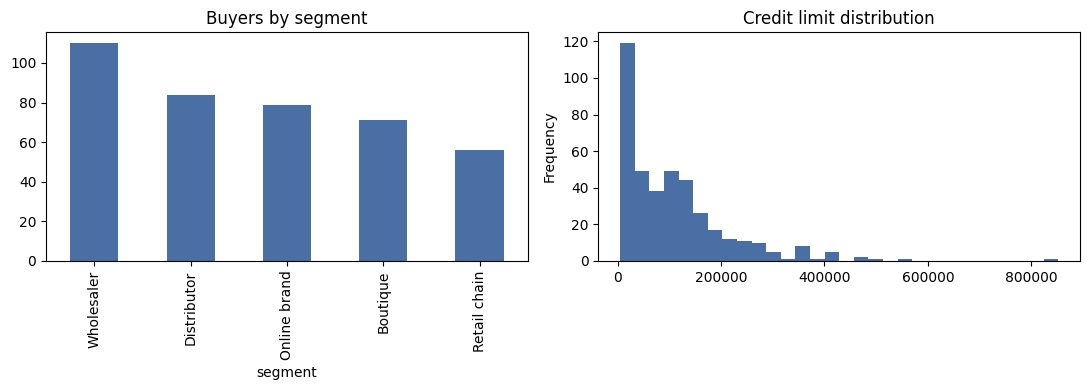

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
buyers["segment"].value_counts().plot.bar(ax=axes[0], color="#4a6fa5")
axes[0].set_title("Buyers by segment")
buyers["credit_limit"].plot.hist(bins=30, ax=axes[1], color="#4a6fa5")
axes[1].set_title("Credit limit distribution")
plt.tight_layout()


### Payment lateness

Most invoices are paid close to on time; a minority run very late or never get paid at all --
the classic long right tail that makes this a rare-event problem, not a balanced one.

6.7% of invoices in the dataset are still unpaid as of the data end date


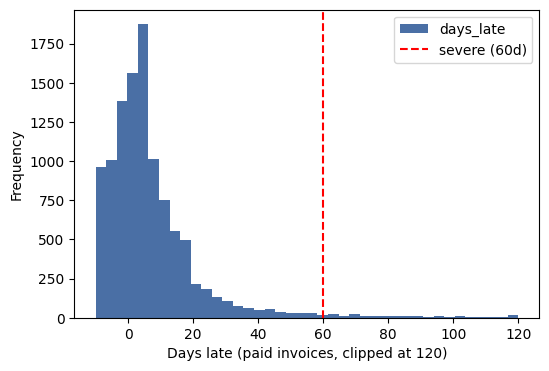

In [5]:
paid = invoices.dropna(subset=["paid_date"]).copy()
paid["days_late"] = (paid["paid_date"] - paid["due_date"]).dt.days
unpaid_pct = invoices["paid_date"].isna().mean()

fig, ax = plt.subplots()
paid["days_late"].clip(-15, 120).plot.hist(bins=40, ax=ax, color="#4a6fa5")
ax.axvline(SETTINGS.label.severe_days, color="red", linestyle="--", label=f"severe ({SETTINGS.label.severe_days}d)")
ax.set_xlabel("Days late (paid invoices, clipped at 120)")
ax.legend()
print(f"{unpaid_pct:.1%} of invoices in the dataset are still unpaid as of the data end date")


## 2. Label definition

We predict, as of a snapshot date, whether a buyer will have **any invoice land severely
delinquent** (unpaid, or paid more than `severe_days` late) among invoices due in the next
`horizon_days`. See `creditrisk/model.py::make_labels`.

This is deliberately a forward-looking, buyer-level label -- not "is this invoice late right
now" -- because the decision it supports (credit limit, hold, collections priority) is about a
buyer's near-future behaviour, not a single invoice.

Overall bad rate: 4.4% across 32 snapshots, 400 unique buyers


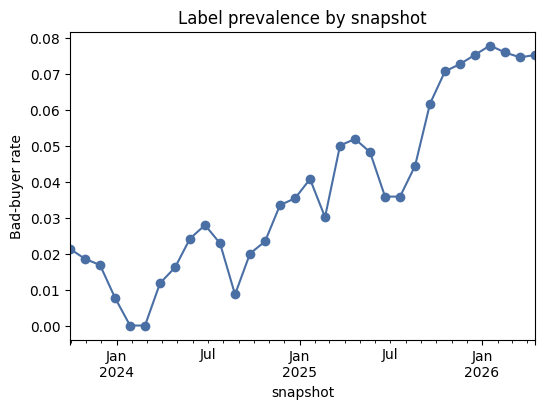

In [6]:
data_end = data_end_date(invoices)
snaps = snapshot_dates(invoices, data_end)

# bad-rate per snapshot, to check the label isn't drifting wildly over time
ds_preview = build_dataset(buyers, invoices, snaps)
rate_by_snap = ds_preview.groupby("snapshot")["label"].mean()
fig, ax = plt.subplots()
rate_by_snap.plot(ax=ax, marker="o", color="#4a6fa5")
ax.set_ylabel("Bad-buyer rate")
ax.set_title("Label prevalence by snapshot")
print(f"Overall bad rate: {ds_preview['label'].mean():.1%} across {len(snaps)} snapshots, {ds_preview['buyer_id'].nunique()} unique buyers")


## 3. Features

All features are computed strictly from information available *as of* the snapshot date --
see `creditrisk/features.py` and the `test_no_lookahead` test in `tests/test_features.py`.

In [7]:
cols = feature_columns(ds_preview.drop(columns=["label", "snapshot"]))
ds_preview[cols].describe().T[["mean", "std", "min", "50%", "max"]]


,mean,std,min,50%,max
credit_limit,111705.751954,104136.405198,5000.000000,91000.000000,8.520000e+05
payment_terms_days,41.709835,11.176255,30.000000,45.000000,6.000000e+01
tenure_days,432.723136,278.580576,0.000000,390.000000,1.202000e+03
avg_days_late_12m,5.765205,8.795110,-10.000000,3.714286,9.560000e+01
max_days_late_12m,20.794790,18.996825,-10.000000,16.000000,1.910000e+02
pct_late_12m,0.320371,0.277820,0.000000,0.266667,1.000000e+00
pct_very_late_12m,0.040700,0.123553,0.000000,0.000000,1.000000e+00
avg_days_late_90d,5.424823,9.361151,-10.000000,3.333333,8.400000e+01
late_trend,-1.120155,10.500779,-114.333333,-0.600000,6.550000e+01
open_balance,74035.862967,99545.757928,0.000000,37900.390000,1.141401e+06


## 4. Baseline vs. model

Three candidates on the same time-based hold-out (last 4 snapshots, with a `horizon_days` gap so
no training label's outcome window overlaps the test period):

1. **Rule**: average days late over the trailing 90 days (a single number a credit team might
   already track by hand).
2. **Logistic regression**: linear, interpretable, a fair comparison for "do we need a
   nonlinear model at all".
3. **XGBoost**: the model actually used in `app.py`.

In [8]:
test_start = snaps[-SETTINGS.n_wf_folds]
horizon = pd.Timedelta(days=SETTINGS.label.horizon_days)
train_ds = ds_preview[ds_preview["snapshot"] <= test_start - horizon]
test_ds = ds_preview[ds_preview["snapshot"] >= test_start]

X_train, y_train = train_ds[cols].fillna(0), train_ds["label"]
X_test, y_test = test_ds[cols].fillna(0), test_ds["label"]

rule_score = test_ds["avg_days_late_90d"].fillna(0)

logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
logit.fit(X_train, y_train)
logit_score = logit.predict_proba(X_test)[:, 1]

xgb = new_model().fit(train_ds[cols], y_train)
xgb_score = xgb.predict_proba(test_ds[cols])[:, 1]

comparison = pd.DataFrame([
    {"model": "Rule: avg days late (90d)", "roc_auc": roc_auc_score(y_test, rule_score), "pr_auc": average_precision_score(y_test, rule_score)},
    {"model": "Logistic regression", "roc_auc": roc_auc_score(y_test, logit_score), "pr_auc": average_precision_score(y_test, logit_score)},
    {"model": "XGBoost (used in app.py)", "roc_auc": roc_auc_score(y_test, xgb_score), "pr_auc": average_precision_score(y_test, xgb_score)},
]).set_index("model").round(3)
comparison


,roc_auc,pr_auc
model,,
Rule: avg days late (90d),0.839,0.610
Logistic regression,0.860,0.663
XGBoost (used in app.py),0.894,0.719


XGBoost's edge over logistic regression here comes mostly from interactions the linear model
can't capture (e.g. lateness trend matters more when utilisation is already high), not from the
features themselves -- both models see the same table.

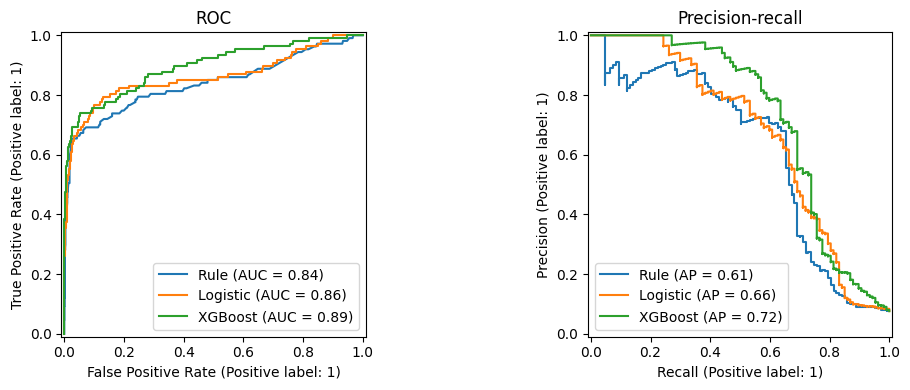

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, s in [("Rule", rule_score), ("Logistic", logit_score), ("XGBoost", xgb_score)]:
    RocCurveDisplay.from_predictions(y_test, s, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, s, name=name, ax=axes[1])
axes[0].set_title("ROC")
axes[1].set_title("Precision-recall")
plt.tight_layout()


## 5. Is the hold-out result stable?

One split, ~350-400 test buyers, is not a lot of data to trust a single ROC-AUC number. Two
checks: walk-forward validation (retrain and re-test on each of the last few snapshots, not just
one), and a bootstrap confidence interval on the single hold-out.

In [10]:
wf = evaluate.walk_forward_eval(buyers, invoices)
wf


,snapshot,n_train,n_test,base_rate,roc_auc,pr_auc
0,2026-01-17,6443,360,0.077778,0.899849,0.658105
1,2026-02-16,6801,356,0.075843,0.907351,0.784649
2,2026-03-18,7160,349,0.074499,0.889855,0.734256
3,2026-04-17,7520,346,0.075145,0.884495,0.741852


In [11]:
print(f"Walk-forward ROC-AUC: {wf['roc_auc'].mean():.3f} +/- {wf['roc_auc'].std():.3f} across {len(wf)} folds")

ci = evaluate.bootstrap_auc_ci(y_test, xgb_score)
print(f"Bootstrap 95% CI on the hold-out ROC-AUC: [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}] (point={ci['point']:.3f})")


Walk-forward ROC-AUC: 0.895 +/- 0.010 across 4 folds


Bootstrap 95% CI on the hold-out ROC-AUC: [0.853, 0.931] (point=0.894)


## 6. Calibration and risk bands

A score used to gate credit decisions should mean roughly what it says: a buyer scored 0.30
should default close to 30% of the time. And the Low/Medium/High bands should be monotonic and
well separated out-of-sample.

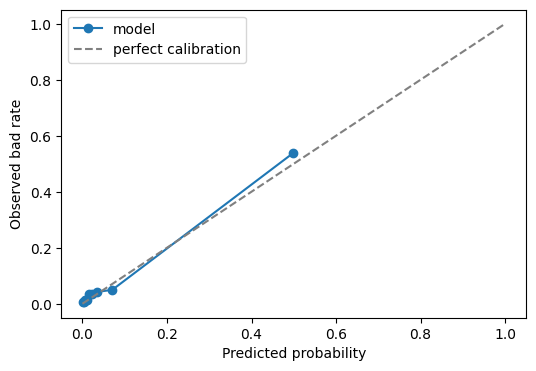

,n,bad_rate
band,,
Low,1295,0.025483
Medium,47,0.297872
High,69,0.869565


In [12]:
calib = evaluate.calibration_table(y_test, xgb_score)
fig, ax = plt.subplots()
ax.plot(calib["predicted"], calib["observed"], marker="o", label="model")
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed bad rate")
ax.legend()
plt.show()

evaluate.band_validation(y_test, xgb_score)


## 7. What drives the score: SHAP

Global feature importance on the hold-out set, matching the per-buyer reason codes shown in the
dashboard (`creditrisk/scoring.py::_reasons`).

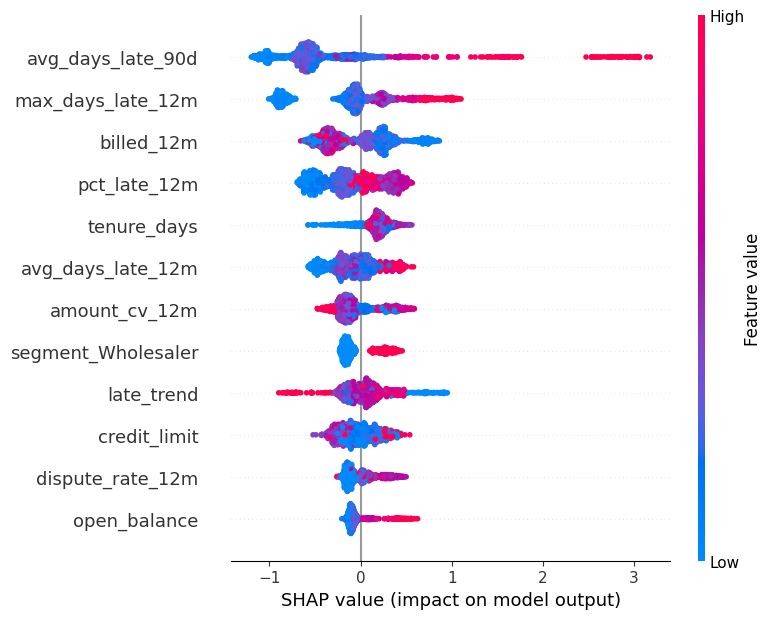

In [13]:
import shap

explainer = shap.TreeExplainer(xgb)
sv = explainer.shap_values(X_test)
shap.summary_plot(sv, X_test, show=False, max_display=12)
plt.tight_layout()


## 8. From score to decision: a cost-based threshold

The app uses fixed score cut-offs (Low/Medium/High) for readability, but the actual decision --
where to draw the "restrict credit" line -- should reflect the asymmetry between the two error
types: missing a real default is expensive (lost principal), wrongly restricting a good buyer is
cheaper (lost margin on that one relationship, not the whole receivable). See
`config.CostConfig` for the illustrative unit costs and `evaluate.cost_curve` for the sweep.

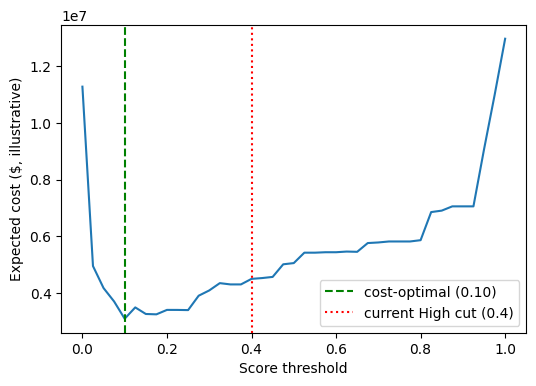

Cost-optimal threshold under the illustrative cost assumptions: 0.10


In [14]:
cost = evaluate.optimal_threshold(y_test, xgb_score, test_ds["open_balance"])
curve = cost["curve"]
fig, ax = plt.subplots()
ax.plot(curve["threshold"], curve["total_cost"])
ax.axvline(cost["threshold"], color="green", linestyle="--", label=f"cost-optimal ({cost['threshold']:.2f})")
ax.axvline(SETTINGS.band.high_cut, color="red", linestyle=":", label=f"current High cut ({SETTINGS.band.high_cut})")
ax.set_xlabel("Score threshold")
ax.set_ylabel("Expected cost ($, illustrative)")
ax.legend()
plt.show()
print(f"Cost-optimal threshold under the illustrative cost assumptions: {cost['threshold']:.2f}")


## 9. Limitations

- **Synthetic data.** All numbers here describe how the pipeline behaves on data I generated to
  have the right *shape* (lateness trends, dispute correlation, a minority of buyers going bad) --
  not real repayment behaviour. Re-run this notebook on real invoice history before trusting the
  numbers.
- **Label lag.** A buyer's outcome isn't known for `horizon_days + severe_days` days after a
  snapshot, so the model is always trained on buyers whose fate was resolved a while ago -- it
  reacts to a regime shift with a delay of a few months, not immediately.
- **Cost assumptions are placeholders.** `loss_given_default` and `margin_on_revenue` in
  `config.CostConfig` are illustrative; the cost-optimal threshold moves a lot if those change.
- **No external bureau/macro data.** Everything is derived from the buyer's own invoice history;
  a real deployment would likely add credit bureau scores, industry risk, or FX/country risk for
  exporters.
